# Libraries

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import seaborn as sns
import scipy as sci

### Activate latex font format

Do you want plot with latex font format? Use the cell bellow:

In [2]:
mpl.rcParams.update({
                        'font.family': 'serif',
                        'mathtext.fontset': 'cm',
                        'axes.unicode_minus': False
                    })

# Dataset upload and computing error model

In [3]:
data = pd.read_excel('data_models_rv2.xlsx', sheet_name='Modelos')
data.columns = data.columns.str.lower().str.replace(' ', '-')
data['wnum/wexp'] = data['fib-model-code-2020-(mm)'] / data['output:-w_exp-(mm)']
data.head()

,autor,output:-w_exp-(mm),fib-model-code-2020-(mm),wexp_menos_wfib2020,fib-model-code-2020--com-ts-variável-(mm),wexp_menos_wfib2020ts,norma-chinesa-(mm),wnum/wexp
0,Viga S200-1.76-20 - Sokolov et al (2021),0.16,0.086159,0.073841,0.102130,0.057870,NaN,0.538496
1,NaN,0.23,0.147127,0.082873,0.190783,0.039217,NaN,0.639681
2,NaN,0.24,0.155568,0.084432,0.203058,0.036942,NaN,0.648201
3,NaN,0.27,0.196838,0.073162,0.263069,0.006931,NaN,0.729030
4,NaN,0.35,0.277502,0.072498,0.380363,-0.030363,NaN,0.792864


# Charts

### Predict versus Experimental

TypeError: '<=' not supported between instances of 'str' and 'float'

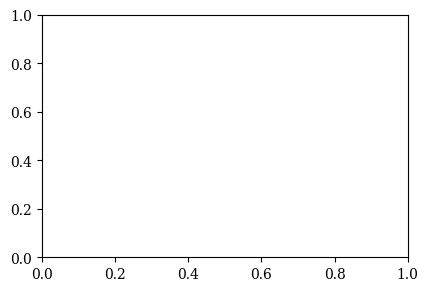

In [4]:
dpi = 600               # Change as you wish
b_cm = 12                       # Change as you wish
h_cm = 8                        # Change as you wish
inches_to_cm = 1 / 2.54
b_input = b_cm * inches_to_cm
h_input = h_cm * inches_to_cm
label_x = 'Observed'            # Change as you wish
label_y = 'Predicted'           # Change as you wish
size_label = 14                 # Change as you wish
color_label = 'blue'            # or hexadecimal. Change as you wish
size_axis = 10                  # Change as you wish
color_axis = 'red'              # or hexadecimal. Change as you wish
size_line = 4           # Change as you wish
style_line = '--'       # Change as you wish
color_line = 'red'      # or hexadecimal. Change as you wish
labels_legend = [r'$R^2$=0.98']   # Change as you wish
size_legend = 10                # Change as you wish
location_legend = 'upper left'  # Change as you wish - 'best' look up by the best fit
fig, ax = plt.subplots(figsize=(b_input, h_input))
lims = [
            min(data.min()),
            max(data.max())
        ]   

# Config axis
ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)

# Config grid
on_or_off = True
plt.grid(on_or_off, which='both', linestyle='-', linewidth=0.5)

# Plot data y = x and scatter
ax.plot(lims, lims, linewidth=size_line, linestyle=style_line, color=color_line,)
ax.scatter(data["output:-w_exp-(mm)"], data["fib-model-code-2020-(mm)"], alpha=alpha_scatter, color=color_scatter, s=size_scatter, label=labels_legend[0])
ax.legend(fontsize=size_legend, loc=location_legend)

# Save. Do you need save? Use the cell bellow:
fig.savefig('z_scatter-line_fib_model_2020.png', dpi=dpi, bbox_inches='tight')
plt.show()

### KDE numerical model - original model

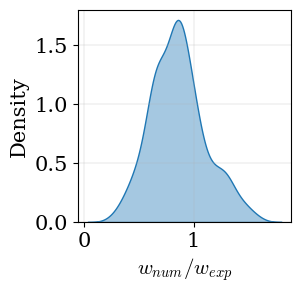

In [ ]:
dpi = 600               
name = 'kde_fib_model_2020'

b_cm = 7            
h_cm = 7
inches_to_cm = 1 / 2.54
b_input = b_cm * inches_to_cm
h_input = h_cm * inches_to_cm

label_y = 'Density'
label_x = '$w_{num}/w_{exp}$'   
size_label = 15
color_label = 'black'
size_axis = 15
color_axis = 'black'           

labels_legend = ['fib Model 2020']   
size_legend = 9                
location_legend = 'upper right'  

fig, ax = plt.subplots(figsize=(b_input, h_input))
ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)
on_or_off = True
plt.grid(on_or_off, which='both', linestyle='-', linewidth=0.2)
sns.kdeplot(data=data, x='wnum/wexp', fill=True, alpha=0.4, ax=ax, label=labels_legend[0])
# ax.legend(fontsize=size_legend, loc=location_legend)
fig.savefig(f'z_{name}.png', dpi=dpi, bbox_inches='tight')
plt.show()

# Goodness-of-fit

### Anderson-Darling test

Normal

In [ ]:
# alpha = 5
# res = sci.stats.anderson(np.log(data['wnum/wexp']), dist="norm")
# stat = res.statistic
# crit = res.critical_values[res.significance_level == alpha][0]
# decision = "Accepted" if stat < crit else "Rejected"
# print(f"AD Statistic: {stat:.4f}")
# print(f"Critical Value at {alpha}% significance level: {crit:.4f}")
# print(f"Null Hypothesis: {decision}")

### Kolmogorov-Smirnov test

t-student

In [ ]:
x = data['wnum/wexp'].values
df, loc, scale = sci.stats.t.fit(x)
print(f"\nFitted Student-t parameters:\nDegrees of freedom: {df:.4f}, Location: {loc:.4f}, Scale: {scale:.4f}")
ks_stat, ks_p = sci.stats.kstest(x, 't', args=(df, loc, scale))
print("\nKolmogorov-Smirnov Test for Student-t Distribution:")
print(f"Student-t KS statistic: {ks_stat:.4f}")
print(f"p-value: {ks_p:.4f}")


Fitted Student-t parameters:
Degrees of freedom: 69.7874, Location: 0.8552, Scale: 0.2454

Kolmogorov-Smirnov Test for Student-t Distribution:
Student-t KS statistic: 0.0543
p-value: 0.2580


Normal

In [ ]:
x = data['wnum/wexp'].values
loc, scale = sci.stats.norm.fit(x)
print(f"\nFitted Normal parameters:\nLocation: {loc:.4f}, Scale: {scale:.4f}")
ks_stat, ks_p = sci.stats.kstest(x, 'norm', args=(loc, scale))
print("\nKolmogorov-Smirnov Test for Normal Distribution:")
print(f"Normal KS statistic: {ks_stat:.4f}")
print(f"p-value: {ks_p:.4f}")


Fitted Normal parameters:
Location: 0.8566, Scale: 0.2489

Kolmogorov-Smirnov Test for Normal Distribution:
Normal KS statistic: 0.0576
p-value: 0.1998


Log-normal

In [ ]:
x = data['wnum/wexp'].values
shape, loc, scale = sci.stats.lognorm.fit(x)
print(f"\nFitted Lognormal parameters:\nShape: {shape:.4f}, Location: {loc:.4f}, Scale: {scale:.4f}")
ks_stat, ks_p = sci.stats.kstest(x, 'lognorm', args=(shape, loc, scale))
print("\nKolmogorov-Smirnov Test for Lognormal Distribution:")
print(f"Lognormal KS statistic: {ks_stat:.4f}")
print(f"p-value: {ks_p:.4f}")


Fitted Lognormal parameters:
Shape: 0.1404, Location: -0.9087, Scale: 1.7479

Kolmogorov-Smirnov Test for Lognormal Distribution:
Lognormal KS statistic: 0.0340
p-value: 0.8115


### Genetate statistics for Lognormal

In [ ]:
mu = np.log(scale)
sigma = shape

mean = loc + np.exp(mu + 0.5*sigma**2)
var = (np.exp(sigma**2) - 1) * np.exp(2*mu + sigma**2)
std = np.sqrt(var)

print("\nLognormal Distribution Moments after fitting:")

Lognormal Distribution Moments after fitting:
Mean = 0.859
Std  = 0.249print(f"Mean = {mean:.3f}")
print(f"Std  = {std:.3f}")


Lognormal Distribution Moments after fitting:
Mean = 0.859
Std  = 0.249


#### Generate synthetic data

In [ ]:
sigma = np.sqrt(np.log(1 + (std / mean)**2))
mu = np.log(mean) - 0.5 * sigma**2

shape = sigma
loc = 0.0
scale = np.exp(mu)

print(f"shape = {shape:.4f}")
print(f"loc   = {loc:.4f}")
print(f"scale = {scale:.4f}")

n_samples = 20000
synthetic_data = sci.stats.lognorm.rvs(s=shape, loc=loc, scale=scale, size=n_samples)

shape = 0.2849
loc   = 0.0000
scale = 0.8225


In [ ]:
# Double check the fit on the synthetic data
x = synthetic_data.copy()
shape, loc, scale = sci.stats.lognorm.fit(x)
print(f"\nFitted Lognormal parameters:\nShape: {shape:.4f}, Location: {loc:.4f}, Scale: {scale:.4f}")
ks_stat, ks_p = sci.stats.kstest(x, 'lognorm', args=(shape, loc, scale))
print("\nKolmogorov-Smirnov Test for Lognormal Distribution:")
print(f"Lognormal KS statistic: {ks_stat:.4f}")
print(f"p-value: {ks_p:.4f}")


Fitted Lognormal parameters:
Shape: 0.2798, Location: -0.0134, Scale: 0.8387

Kolmogorov-Smirnov Test for Lognormal Distribution:
Lognormal KS statistic: 0.0041
p-value: 0.8922


#### Synthetic data versus original data

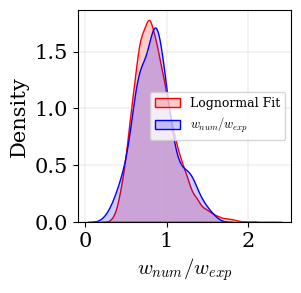

In [ ]:
fig, ax = plt.subplots(figsize=(b_input, h_input))
ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)
on_or_off = True
plt.grid(on_or_off, which='both', linestyle='-', linewidth=0.2)
sns.kdeplot(data=synthetic_data, fill=True, alpha=0.2, color='red', label='Lognormal Fit', ax=ax)
sns.kdeplot(data=list(data['wnum/wexp']), fill=True, alpha=0.2, color='blue', label='$w_{num}/w_{exp}$', ax=ax)
ax.legend(fontsize=size_legend, loc='center right')
fig.savefig(f'z_{name}_gt_versus_lognormal.png', dpi=dpi, bbox_inches='tight')
plt.show()